In [74]:
df = pd.read_excel('/kaggle/input/datasets/itsparmeet007/iris-dataset/Iris.csv.xlsx')
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [75]:
df = df.drop(['Id'],axis=1)
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [76]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
df['Species'] = encoder.fit_transform(df['Species'])
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [77]:
df = df[df['Species'] !=0][['SepalWidthCm','PetalLengthCm','Species']]

In [78]:
df.head()

,SepalWidthCm,PetalLengthCm,Species
50,3.2,4.7,1
51,3.2,4.5,1
52,3.1,4.9,1
53,2.3,4.0,1
54,2.8,4.6,1


In [79]:
print(df['Species'].unique())

[1 2]


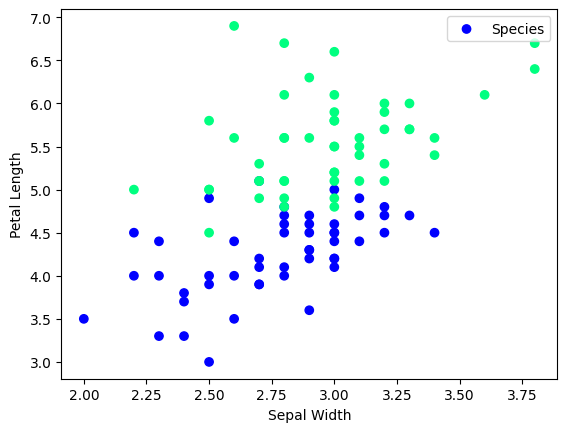

In [80]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.scatter(
    df['SepalWidthCm'],
    df['PetalLengthCm'],
    c= df['Species'],
    label='Species',
    cmap='winter'
)

plt.xlabel('Sepal Width')
plt.ylabel('Petal Length')

plt.legend()
plt.show()

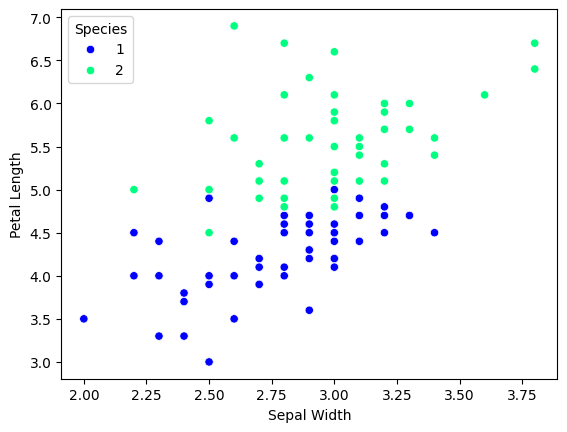

In [81]:
sns.scatterplot(
    data=df,
    x='SepalWidthCm',
    y='PetalLengthCm',
    hue='Species',
    palette='winter'
)

plt.xlabel('Sepal Width')
plt.ylabel('Petal Length')
plt.show()

In [82]:
df

,SepalWidthCm,PetalLengthCm,Species
50,3.2,4.7,1
51,3.2,4.5,1
52,3.1,4.9,1
53,2.3,4.0,1
54,2.8,4.6,1
...,...,...,...
145,3.0,5.2,2
146,2.5,5.0,2
147,3.0,5.2,2
148,3.4,5.4,2


In [83]:
df.sample(100)

,SepalWidthCm,PetalLengthCm,Species
90,2.6,4.4,1
131,3.8,6.4,2
76,2.8,4.8,1
113,2.5,5.0,2
89,2.5,4.0,1
...,...,...,...
77,3.0,5.0,1
92,2.6,4.0,1
141,3.1,5.1,2
143,3.2,5.9,2


In [84]:
df = df.sample(100)
df_train = df.iloc[:60,:].sample(10) # for training models
df_val = df.iloc[60:80,:].sample(5) # for calculating accuracy
df_test = df.iloc[80:,:].sample(5) # for testing 

In [85]:
df_train

,SepalWidthCm,PetalLengthCm,Species
108,2.5,5.8,2
122,2.8,6.7,2
87,2.3,4.4,1
99,2.8,4.1,1
72,2.5,4.9,1
67,2.7,4.1,1
115,3.2,5.3,2
90,2.6,4.4,1
104,3.0,5.8,2
145,3.0,5.2,2


In [86]:
df_val

,SepalWidthCm,PetalLengthCm,Species
61,3.0,4.2,1
50,3.2,4.7,1
111,2.7,5.3,2
53,2.3,4.0,1
92,2.6,4.0,1


In [87]:
df_test

,SepalWidthCm,PetalLengthCm,Species
63,2.9,4.7,1
75,3.0,4.4,1
94,2.7,4.2,1
66,3.0,4.5,1
86,3.1,4.7,1


In [88]:
X_test = df_val.iloc[:,0:2].values
y_test = df_val.iloc[:,-1].values

In [89]:
X_test

array([[3. , 4.2],
       [3.2, 4.7],
       [2.7, 5.3],
       [2.3, 4. ],
       [2.6, 4. ]])

# **Case 1: Bagging**

In [90]:
df_bag0 = df_train.sample(8,replace=True)
X0 = df_bag.iloc[:,0:2]
y0 = df_bag.iloc[:,-1]
df_bag0

,SepalWidthCm,PetalLengthCm,Species
72,2.5,4.9,1
104,3.0,5.8,2
115,3.2,5.3,2
108,2.5,5.8,2
122,2.8,6.7,2
99,2.8,4.1,1
87,2.3,4.4,1
99,2.8,4.1,1


In [91]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score

In [92]:
dt_bag0 = DecisionTreeClassifier()

In [93]:
def evaluate(clf,X,y):
    clf.fit(X,y)
    plot_tree(clf)
    plt.show()
    plot_decision_regions(X.values,y.values,clf=clf,legend=2)
    y_pred = clf.predict(X_test)
    print(accuracy_score(y_test,y_pred))

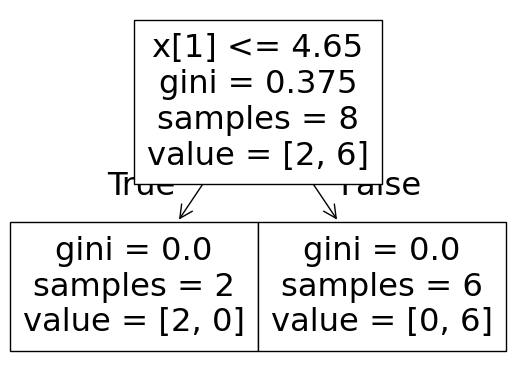

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


0.8


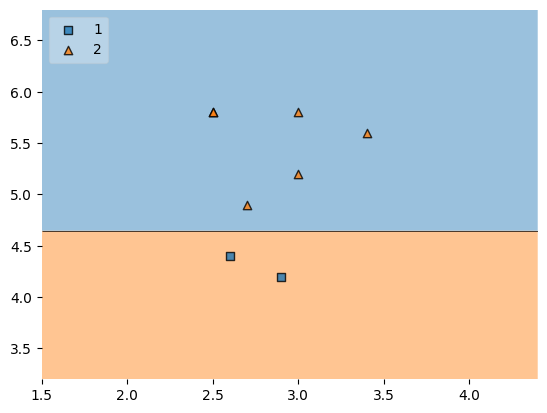

In [94]:
evaluate(df_bag1,X0,y0)

In [95]:
# Data For Tree 1
df_bag1 = df_train.sample(8,replace=True)

X1 = df_bag.iloc[:,0:2]
y1 = df_bag.iloc[:,-1]
df_bag1

,SepalWidthCm,PetalLengthCm,Species
104,3.0,5.8,2
108,2.5,5.8,2
115,3.2,5.3,2
72,2.5,4.9,1
145,3.0,5.2,2
108,2.5,5.8,2
87,2.3,4.4,1
90,2.6,4.4,1


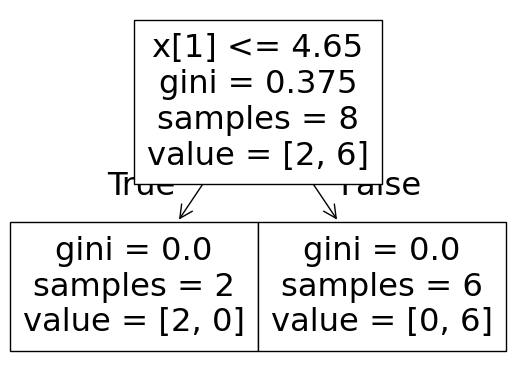

0.8


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


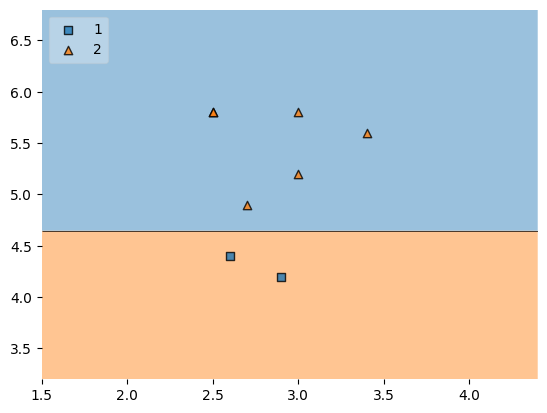

In [96]:
dt_bag1 = DecisionTreeClassifier()
evaluate(dt_bag2,X1,y1)

In [97]:
# Data For Tree 2
df_bag2 = df_train.sample(8,replace=True)

X2 = df_bag.iloc[:,0:2]
y2 = df_bag.iloc[:,-1]
df_bag2

,SepalWidthCm,PetalLengthCm,Species
99,2.8,4.1,1
72,2.5,4.9,1
90,2.6,4.4,1
90,2.6,4.4,1
67,2.7,4.1,1
108,2.5,5.8,2
122,2.8,6.7,2
108,2.5,5.8,2


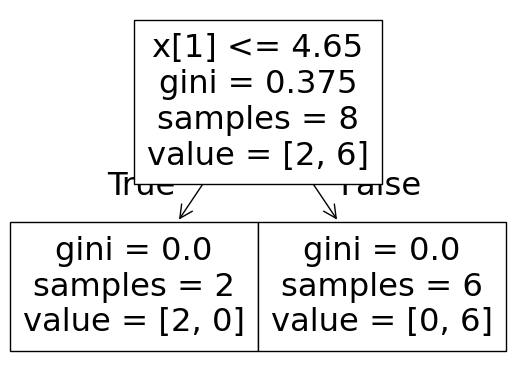

0.8


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


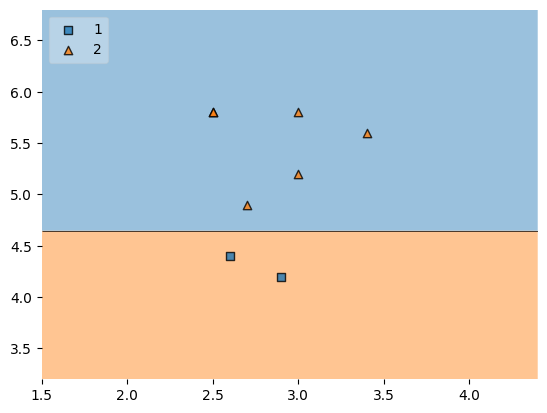

In [98]:
dt_bag2 = DecisionTreeClassifier()
evaluate(dt_bag2,X2,y2)

# **Prediciton** 

In [99]:
df_test

,SepalWidthCm,PetalLengthCm,Species
63,2.9,4.7,1
75,3.0,4.4,1
94,2.7,4.2,1
66,3.0,4.5,1
86,3.1,4.7,1


In [100]:
# Independent Prediction of the first sample of df_test on 3 models
print('Predictor 1',dt_bag1.predict(np.array([2.7,5.1]).reshape(1,2)))
print('Predictor 2',dt_bag2.predict(np.array([2.7,5.1]).reshape(1,2)))
print('Predictor 3',dt_bag3.predict(np.array([2.7,5.1]).reshape(1,2)))

NotFittedError: This DecisionTreeClassifier instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.